<a href="https://colab.research.google.com/github/Khulood-Alkhuzaee/Amazon-Consumer-Insights-Predictive-Model/blob/main/Amazon_Consumer_Insights_Predictive_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Environment Setup & Data Loading



In [1]:
# Import libraries for data processing and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Loading data with error handling for malformed lines
df = pd.read_csv("Amazon.csv", on_bad_lines='skip', engine='python')

# Displaying the first few rows to verify the structure
df.head()


,id,asins,brand,categories,colors,dateAdded,dateUpdated,dimension,ean,keys,...,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username,sizes,upc,weight
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I initially had trouble deciding between the p...,"Paperwhite voyage, no regrets!",NaN,NaN,Cristina M,NaN,NaN,205 grams
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,Allow me to preface this with a little history...,One Simply Could Not Ask For More,NaN,NaN,Ricky,NaN,NaN,205 grams
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,4.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I am enjoying it so far. Great for reading. Ha...,Great for those that just want an e-reader,NaN,NaN,Tedd Gardiner,NaN,NaN,205 grams
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I bought one of the first Paperwhites and have...,Love / Hate relationship,NaN,NaN,Dougal,NaN,NaN,205 grams
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,"Amazon Devices,mazon.co.uk",NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,...,5.0,https://www.amazon.com/Kindle-Paperwhite-High-...,I have to say upfront - I don't like coroporat...,I LOVE IT,NaN,NaN,Miljan David Tanic,NaN,NaN,205 grams


# 2. Data Preprocessing & Cleaning


In [3]:
# 1. Extract numerical weight and unit accurately using Regular Expressions
df['weight_numeric'] = df['weight'].str.extract(r'(\d+\.?\d*)').astype(float)
df['unit'] = df['weight'].str.extract(r'([a-zA-Z]+)')

# 2. Standardize weights to grams (Crucial step before any statistical calculation)
def convert_to_grams(row):
    if row['unit'] == 'ounces':
        return row['weight_numeric'] * 28.35
    return row['weight_numeric']

# Apply the conversion function across the dataframe
df['weight'] = df.apply(convert_to_grams, axis=1)

# Calculate and display the final mean weight
print(f"Mean weight: {df['weight'].mean()}")


Mean weight: 56.03257425742575


# 3. Advanced Descriptive Statistics


I applied the **dropna()** function to handle missing values within the required columns. This step was crucial to ensure that subsequent statistical operations—specifically calculating the **Weighted Average** of ratings—are based on a complete dataset, leading to more accurate and reliable insights.

In [4]:
# Remove missing values from the original dataframe to ensure accuracy
# We use the same 'df' name as defined earlier
df = df.dropna(subset=['reviews.rating', 'weight'])

# Calculate the Weighted Average of ratings based on product weight
weighted_avg = np.average(df['reviews.rating'], weights=df['weight'])
print(f"Weighted Average Rating: {weighted_avg}")

Weighted Average Rating: 4.489243714746072


I calculated the **Trimmed Mean (at 10%)** to obtain a more representative average of product weights. By excluding the top and bottom 10% of the data, I am able to mitigate the impact of extreme outliers that could otherwise skew the statistical results, ensuring a more stable and accurate weight distribution analysis.

In [5]:
# Import the trim_mean function from the scipy library
from scipy.stats import trim_mean

# Calculate the 10% Trimmed Mean to remove the influence of extreme outliers
trim_mean(df['weight'], 0.1)

np.float64(50.074363636363636)

I calculated the **Median** of the weight column to identify the central tendency of the data. As a robust measure, the median is less sensitive to extreme outliers than the standard mean, allowing me to understand the typical product weight more accurately within this dataset.

In [6]:
# Calculate the Median (middle value) for product weights
df["weight"].median()

45.36000000000001

I defined a custom function to calculate the **Weighted Median** . This advanced approach allows me to identify the true central point of the data while accounting for the specific importance (weight) of each entry. It provides a more nuanced and deeper perspective on the weight distribution than a standard median would.

In [7]:
def weighted_median(df, median_col, weight_col):
  df_sorted = df.sort_values(median_col)
  cumsum = df_sorted[weight_col].cumsum()
  cutoff = df_sorted[weight_col].sum() / 2
  return df_sorted[cumsum >= cutoff][median_col].iloc[0]
weighted_median(df, "weight", "reviews.rating")

np.float64(1.75)

I calculated the **Third Quartile (Q3)** , or the **75th Percentile** , for the weight column. This metric indicates that 75% of the products fall at or below this value, providing key insights into the upper distribution of the data and helping me identify the range of higher-end values within the dataset.

In [8]:
# Calculate the 75th Percentile (Q3) for product weights
# This identifies the value below which 75% of the data falls
q3_weight = df['weight'].quantile(0.75)
print(f"75th Percentile (Q3): {q3_weight}")

75th Percentile (Q3): 45.36000000000001


### Statistical Summary of the Dataset

In [9]:
# Generate a descriptive statistical summary for all numerical columns
df.describe()

,ean,reviews.numHelpful,reviews.rating,reviews.userCity,reviews.userProvince,sizes,upc,weight,weight_numeric
count,4.600000e+01,45.000000,67.000000,0.0,0.0,0.0,4.600000e+01,67.000000,67.000000
mean,8.416670e+11,44.355556,4.432836,NaN,NaN,NaN,8.416670e+11,59.562537,47.152985
std,0.000000e+00,140.771439,0.988171,NaN,NaN,NaN,0.000000e+00,80.891097,85.417470
min,8.416670e+11,0.000000,1.000000,NaN,NaN,NaN,8.416670e+11,1.100000,1.100000
25%,8.416670e+11,0.000000,4.000000,NaN,NaN,NaN,8.416670e+11,1.750000,1.600000
50%,8.416670e+11,2.000000,5.000000,NaN,NaN,NaN,8.416670e+11,45.360000,1.750000
75%,8.416670e+11,7.000000,5.000000,NaN,NaN,NaN,8.416670e+11,45.360000,1.750000
max,8.416670e+11,806.000000,5.000000,NaN,NaN,NaN,8.416670e+11,205.000000,205.000000


###Measuring Data Variance:
 I calculated the **Variance** to determine how much the product weights deviate from the mean. This provides a clear numerical value representing the data's spread, which is essential for assessing the consistency of the dataset and understanding the range of variability among products.

In [10]:
# Import variance function from the statistics library
from statistics import variance

# Calculate the variance for product weights to measure data spread
product_weight_variance = variance(df["weight"])
print(f"Variance of product weights: {product_weight_variance}")

Variance of product weights: 6543.369513161465


###Standard Deviation:
 I calculated the **Standard Deviation** to determine the average distance of each data point from the mean. Unlike variance, it is expressed in the same units as the weight data, making it more intuitive for interpreting the spread and understanding how much individual product weights typically vary.

In [11]:
# Import the stdev function from the statistics library
from statistics import stdev

# Calculate the Standard Deviation of weights
weight_standard_deviation = stdev(df["weight"])
print(f"Standard Deviation: {weight_standard_deviation}")

Standard Deviation: 80.89109662479218


###Mean Absolute Deviation (MAD):
 I calculated the **Mean Absolute Deviation** to represent the average distance between each data point and the mean. As a robust measure of variability, MAD is less sensitive to extreme outliers than the standard deviation, offering a more stable perspective on how much the product weights typically vary."

In [12]:
# Import the mean function from the statistics library
from statistics import mean

# Calculate the Mean Absolute Deviation (MAD) manually
# MAD = mean(abs(x - mean(x)))
mad_weight = mean(abs(df["weight"] - mean(df["weight"])))
print(f"Mean Absolute Deviation: {mad_weight}")


Mean Absolute Deviation: 65.12125194920917


###Median Absolute Deviation (Median AD):
I utilized the **Median Absolute Deviation** as a highly robust measure of variability. By focusing on the median rather than the mean, I can provide a more stable estimate of the data spread that remains unaffected by extreme outliers, ensuring the integrity of my analysis even with skewed weight distributions

In [13]:
# Import necessary functions from the numpy library
from numpy import median, absolute

# Calculate the Median Absolute Deviation (Median AD)
# Median AD = median(abs(x - median(x)))
median_ad_weight = median(absolute(df["weight"] - median(df["weight"])))
print(f"Median Absolute Deviation: {median_ad_weight}")

Median Absolute Deviation: 43.61000000000001


###Interquartile Range (IQR):
 I calculated the **Interquartile Range (IQR)** as the difference between the 75th percentile (Q3) and the 25th percentile (Q1). This metric allows me to measure the spread of the middle 50% of the weight data, providing a clear picture of the core distribution and serving as a reliable baseline for identifying potential outliers.

In [14]:
# Calculate the 75th (Q3) and 25th (Q1) percentiles
q3, q1 = np.percentile(df["weight"], [75, 25])

# Calculate the Interquartile Range (IQR)
iqr = q3 - q1

# Display the results
print(f"Q3 (75th Percentile): {q3}")
print(f"Q1 (25th Percentile): {q1}")
print(f"Interquartile Range (IQR): {iqr}")


Q3 (75th Percentile): 45.36000000000001
Q1 (25th Percentile): 1.75
Interquartile Range (IQR): 43.61000000000001


# Part 1: Descriptive Data Analysis


In this section, I translate the statistical metrics into visual representations to better understand the underlying patterns of the dataset. Using libraries like Matplotlib and Seaborn, I focus on visualizing the distribution of product weights and identifying the relationships between different features. This visual exploration is essential for verifying my previous statistical observations, such as the right-skewed distribution and the presence of outliers.

### Data Visualization: Boxplot of Product Weights:
I generated a **Boxplot** to visually inspect the distribution of product weights and identify potential outliers. This chart effectively illustrates the median and the Interquartile Range (IQR) while highlighting values that fall significantly outside the typical range. This visualization serves as a practical confirmation of my previous statistical calculations regarding data spread and skewness.

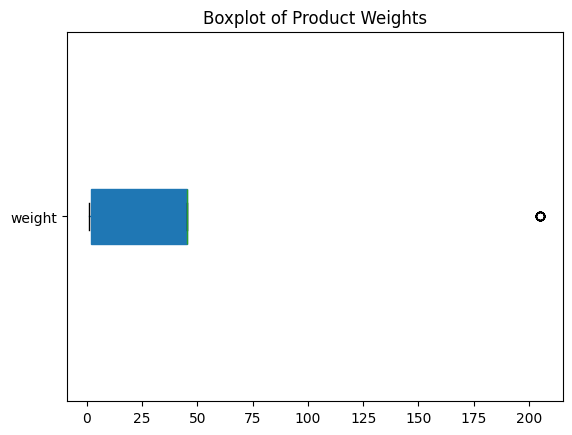

In [15]:
# Generate a Boxplot for the weight column to visualize distribution and outliers
df.boxplot(column="weight", grid=False, vert=False, patch_artist=True)

# Add a title to the plot
import matplotlib.pyplot as plt
plt.title("Boxplot of Product Weights")
plt.show()


To get a better understanding of how product weights are distributed, I divided the data into 10 equal intervals (bins). Creating this **Frequency Distribution Table** allows me to identify which weight ranges are the most common, helping me organize the data effectively before moving forward with more visualizations.

In [16]:
# Create a frequency table by binning the weights into 10 intervals
frequency_table = df.copy()
frequency_table["freq"] = pd.cut(df["weight"], 10)

# Group by the intervals and count the number of products in each
dist_summary = frequency_table.groupby("freq", observed=False).size().reset_index(name='count')

# Display the frequency table
dist_summary


,freq,count
0,"(0.896, 21.49]",33
1,"(21.49, 41.88]",0
2,"(41.88, 62.27]",19
3,"(62.27, 82.66]",0
4,"(82.66, 103.05]",0
5,"(103.05, 123.44]",0
6,"(123.44, 143.83]",0
7,"(143.83, 164.22]",0
8,"(164.22, 184.61]",0
9,"(184.61, 205.0]",15


### Visualizing Weight Distribution (Histogram)
To visually verify the distribution patterns I’ve identified so far, I created the histogram below. This chart allows me to see the shape of the product weights distribution more clearly and confirm if it aligns with the observations from my frequency table and boxplot.

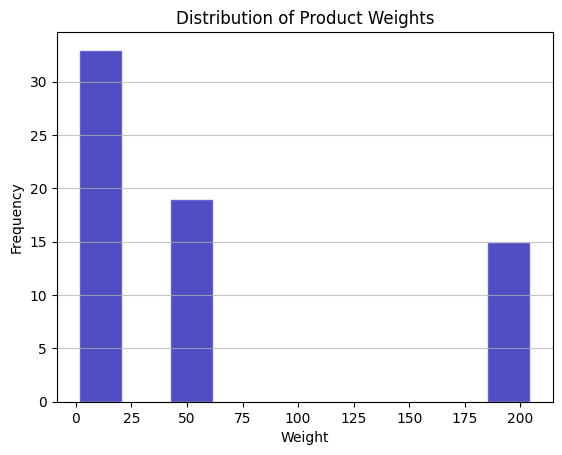

In [17]:
import matplotlib.pyplot as plt

# Histogram
plt.hist(df["weight"], bins=10, color='#0504aa', alpha=0.7, rwidth=0.95, edgecolor='white')

plt.title("Distribution of Product Weights")
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.75)
plt.show()


### Customer Ratings Analysis
To understand customer satisfaction, I decided to visualize the distribution of ratings. Creating this bar chart helps me identify the most frequent rating given by users, providing a clear insight into the overall quality and how our products are being received.

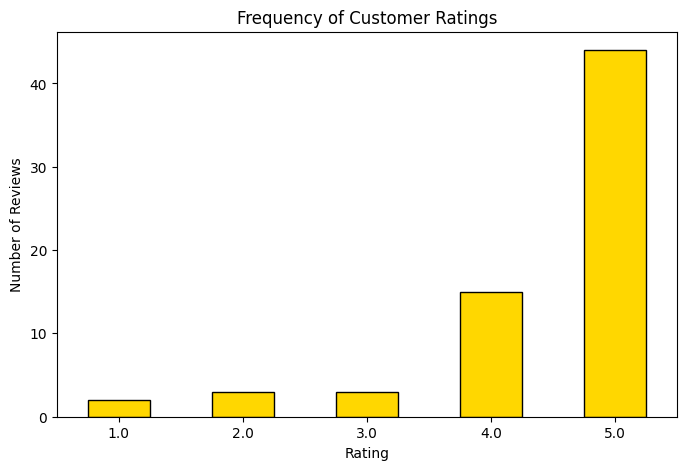

In [18]:
# Count the frequency of each rating
rating_counts = df["reviews.rating"].value_counts().sort_index()

# Plotting the bar chart
plt.figure(figsize=(8, 5))
rating_counts.plot(kind='bar', color='gold', edgecolor='black')

plt.title("Frequency of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.show()


### Weight Distribution with Density (KDE)
To gain a deeper understanding of the weight distribution, I combined a Kernel Density Estimate (KDE) with the histogram. This allows me to visualize the probability density more clearly and identify patterns such as **multi-modality** , which helps confirm if there are multiple clusters in my data.

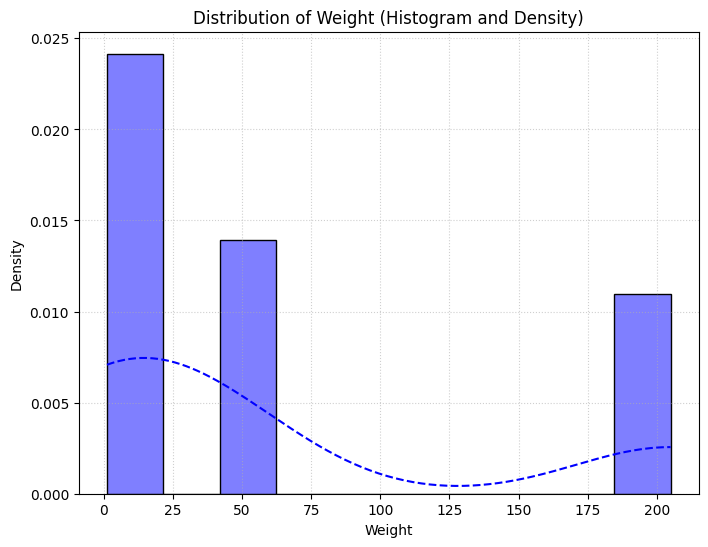

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))


sns.histplot(df["weight"], kde=True, stat='density', ax=ax, color='blue', line_kws={'color': 'red', 'linestyle': '--'})


ax.set_title('Distribution of Weight (Histogram and Density)')
ax.set_xlabel('Weight')
ax.set_ylabel('Density')


plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


###

In [20]:
df["weight"].mode()

,weight
0,1.75


## Part 2: Correlation Analysis


In this section, I will explore the relationships between different variables in the dataset. My goal is to see if there are any significant correlations—for example, between product weight and customer ratings—that could provide deeper insights into the data.

In [21]:

important_df = df[['weight', 'reviews.rating', 'reviews.numHelpful']]


important_df.corr()


,weight,reviews.rating,reviews.numHelpful
weight,1.000000,0.042669,0.016268
reviews.rating,0.042669,1.000000,0.125262
reviews.numHelpful,0.016268,0.125262,1.000000


## 2. Relationship between Weight and Ratings
To visually confirm the weak correlation I found in the matrix, I used a **Scatter Plot** This helps me see if certain weight ranges consistently receive higher or lower ratings, or if the points are just scattered without a clear pattern.


<Axes: xlabel='weight', ylabel='reviews.rating'>

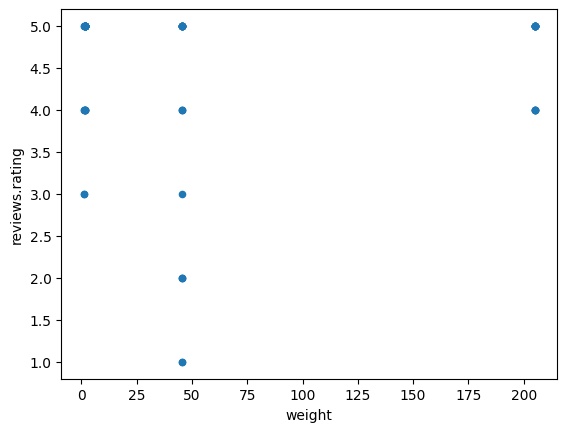

In [22]:
df.plot.scatter(x="weight", y="reviews.rating")

##  Relationship between Weight and Review Helpfulness
To explore the strongest relationship I found in my data, I used this **Scatter Plot** how product weight influences the number of 'Helpful' votes a review receives. I want to visualize if heavier products tend to generate more useful feedback for other users.

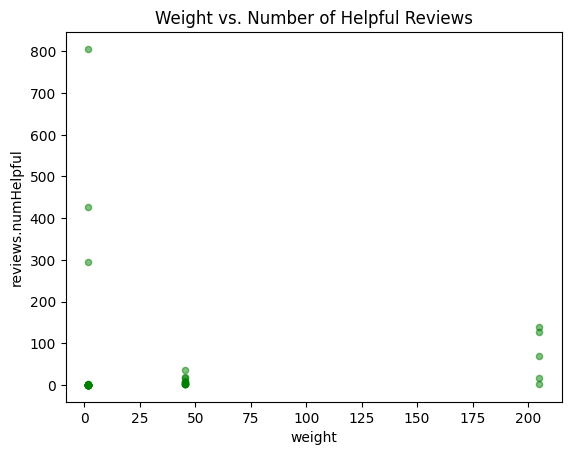

In [23]:
df.plot.scatter(x="weight", y="reviews.numHelpful", color='green', alpha=0.5)
plt.title('Weight vs. Number of Helpful Reviews')
plt.show()


## 3. Density Analysis: Weight vs. Ratings (Hexbin Plot)
To better visualize where the majority of my data points cluster, I used a **Hexbin Plot**. This helps me identify the most common combinations of weight and rating by using color intensity, providing a clearer picture of the data density that a standard scatter plot might miss.


<Axes: xlabel='weight', ylabel='reviews.rating'>

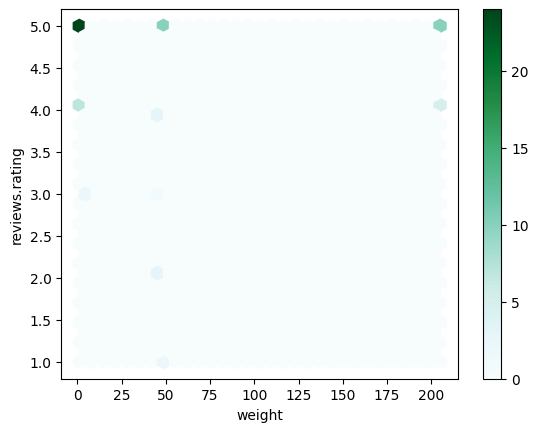

In [24]:

df.plot.hexbin(x="weight", y="reviews.rating", gridsize=30, sharex=False)

## 4.  Bivariate Density Analysis: Weight vs. Rating
While my scatter plot shows individual points, I used this **2D KDE Plot** to visualize the underlying density of the data. This helps me identify the 'hotspots' where the majority of products cluster in terms of weight and satisfaction, providing a smoother and more continuous view of the relationships.


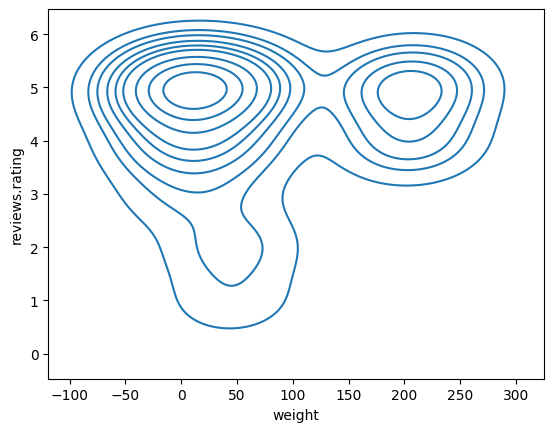

In [25]:
ax = sns.kdeplot(x=df["weight"], y=df["reviews.rating"])

## 5.  Visualizing Correlations: Heatmap
To summarize all the relationships I’ve explored at once, I used a **Heatmap**. This provides me with a clear, color-coded overview of how all numerical features interact with each other, making it easy to spot the most significant correlations at a single glance.


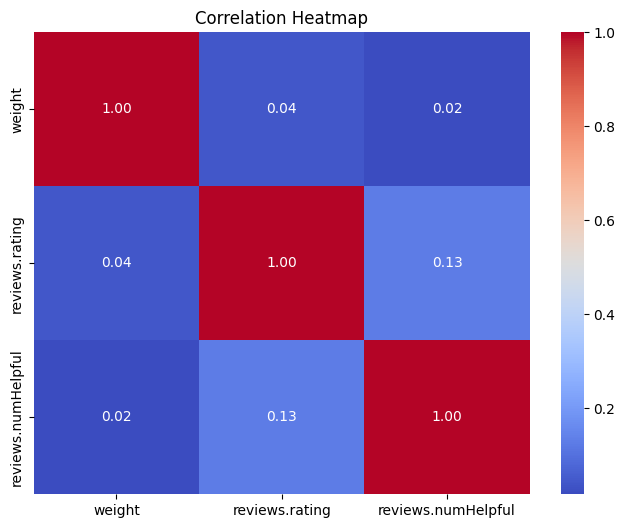

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 6))
sns.heatmap(important_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()


##  6. Categorical Distribution: Brand vs. Weight
To better understand my product inventory, I used a **Pivot Table** to see how products are distributed across different brands and their respective weight categories. This helps me identify which brands dominate specific weight ranges in my dataset.

In [27]:
crosstab = df.pivot_table(index='brand', columns='weight',
aggfunc=lambda x: len(x), margins=True)
crosstab.fillna(0)

/tmp/ipykernel_20629/1201884324.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  crosstab.fillna(0)


asins                      categories                       ... upc  \
weight   1.1 1.75 45.36 205.0 All        1.1 1.75 45.36 205.0 All  ... 1.1   
brand                                                              ...       
Amazon     6   27    19    15   0          6   27    19    15   0  ...   6   
All        0    0     0     0   0          0    0     0     0   0  ...   0   

                            weight_numeric                       
weight 1.75 45.36 205.0 All            1.1 1.75 45.36 205.0 All  
brand                                                            
Amazon   27    19    15   0              6   27    19    15   0  
All       0     0     0   0              0    0     0     0   0  

[2 rows x 135 columns]

## 7. Distribution Density of Product Weights
To see the actual 'shape' of my data and where most products fall in terms of weight, I used a **Violin Plot**. This allows me to see the density and concentration of my inventory much more clearly than a simple histogram, highlighting exactly where the weight values are most frequent.


<Axes: xlabel='weight'>

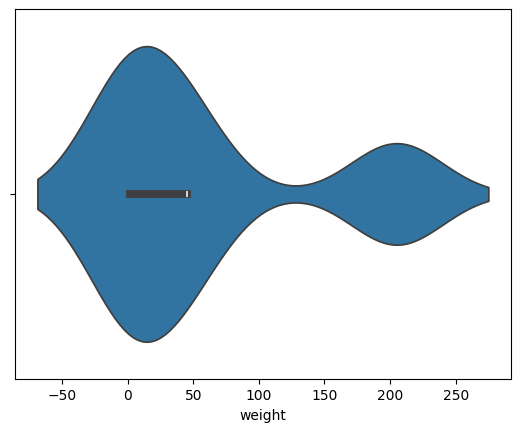

In [28]:
sns.violinplot(x='weight', data=df)

## Part 3: Data Transformation and Feature Engineering
In this section, I applied advanced Python techniques using **Lambda functions** and the **split()** method. My first goal was to clean the 'weight' column by extracting the numeric values and removing any unnecessary characters. This step is crucial because it transforms raw text into a format that my statistical models can actually process.


In [29]:
df['weight_numeric'] = df['weight'].apply(lambda x: float(str(x).split(' ')[0]) if len(str(x).split(' ')) >= 1 else x)


df[['weight', 'weight_numeric']].head()


,weight,weight_numeric
0,205.0,205.0
1,205.0,205.0
2,205.0,205.0
3,205.0,205.0
4,205.0,205.0


## Text Analysis: Extracting Review Length
In the next stage of my analysis, I used a **Lambda function** to process the customer reviews. By splitting the text strings, I created a new feature called **'review_word_count'** This allows me to measure the depth of feedback provided by users and understand if longer, more detailed reviews correlate with other factors like ratings or helpfulness.

In [30]:
df['weight_numeric'] = df['weight'].apply(lambda x: float(str(x).split(' ')[0]) if pd.notnull(x) else x)


df['review_word_count'] = df['reviews.text'].apply(lambda x: len(str(x).split(' ')) if pd.notnull(x) else 0)


df[['weight', 'weight_numeric', 'reviews.text', 'review_word_count']].head()


,weight,weight_numeric,reviews.text,review_word_count
0,205.0,205.0,I initially had trouble deciding between the p...,193
1,205.0,205.0,Allow me to preface this with a little history...,272
2,205.0,205.0,I am enjoying it so far. Great for reading. Ha...,35
3,205.0,205.0,I bought one of the first Paperwhites and have...,310
4,205.0,205.0,I have to say upfront - I don't like coroporat...,352


##  Final Analysis: Impact of Review Depth on Engagement
To conclude my bivariate analysis, I visualized the relationship between the **length of a review** (word count) and its **perceived helpfulness**. This final step helps me understand if consumers truly value detailed, in-depth feedback over short comments, providing a clear answer to how review depth impacts community engagement.


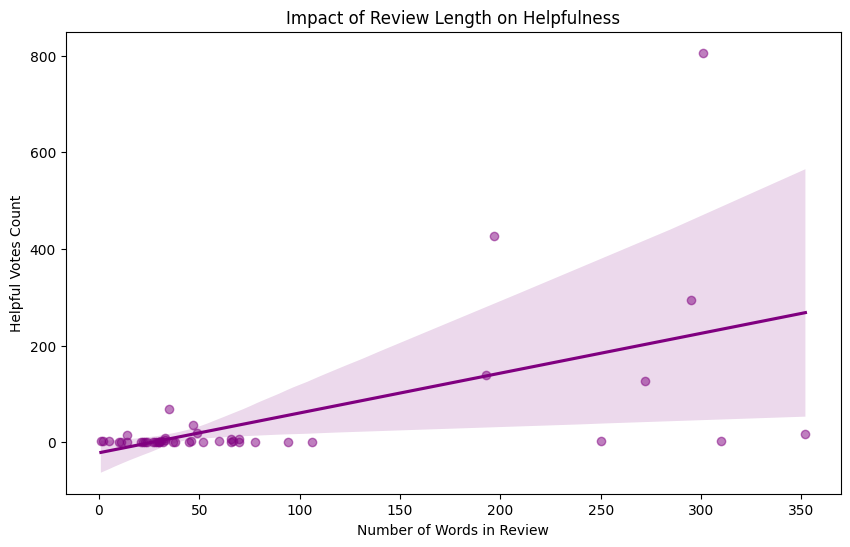

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure 'review_word_count' column exists
df['review_word_count'] = df['reviews.text'].apply(lambda x: len(str(x).split(' ')) if pd.notnull(x) else 0)

plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='review_word_count', y='reviews.numHelpful', color='purple', scatter_kws={'alpha':0.5})
plt.title('Impact of Review Length on Helpfulness')
plt.xlabel('Number of Words in Review')
plt.ylabel('Helpful Votes Count')
plt.show()

### Statistical Significance Testing
To add a deeper level of scientific rigor to my analysis, I applied an **Independent T-Test** to compare the mean ratings between the two most frequent categories in my dataset. My goal was to determine if the observed differences in customer satisfaction are **Statistically Significant ({alpha = 0.05})** or simply due to random variation. This step ensures that my findings are reliable and not just a result of chance.

In [32]:
# --- Step 1: Library Import ---
import scipy.stats as ss

# --- Step 2: Automated Group Selection ---
# Get the top 2 unique categories to ensure groups are NOT empty
top_categories = df['categories'].value_counts().index[:2]
cat1, cat2 = top_categories[0], top_categories[1]

print(f"Comparing: {cat1} VS {cat2}")

# --- Step 3: Defining Comparison Groups ---
group_a = df[df['categories'] == cat1]['reviews.rating'].dropna()
group_b = df[df['categories'] == cat2]['reviews.rating'].dropna()

# --- Step 4: Execution of T-Test ---
t_stat, p_val = ss.ttest_ind(group_a, group_b, equal_var=False, nan_policy='omit')

# --- Step 5: Professional Output Display ---
print(f'T-Statistic: {t_stat:.4f}')
print(f'P-Value: {p_val:.4f}')

# --- Step 6: Final Decision Logic ---
if p_val < 0.05:
    print("Conclusion: Statistically Significant (Reject Null Hypothesis)")
else:
    print("Conclusion: Not Statistically Significant (Fail to Reject Null Hypothesis)")


Comparing: Amazon Devices,Home,Smart Home & Connected Living,Smart Hubs & Wireless Routers,Smart Hubs,Home Improvement,Home Safety & Security,Alarms & Sensors,Home Security,Amazon Echo,Home, Garage & Office,Smart Home,Voice Assistants,Amazon Tap,Electronics Features,TVs & Electronics,Portable Audio & Electronics,MP3 Player Accessories,Home Theater & Audio,Speakers,Featured Brands,Electronics,Kindle Store,Frys,Electronic Components,Home Automation,Electronics, Tech Toys, Movies, Music,Audio,Bluetooth Speakers VS Amazon Devices & Accessories,Amazon Device Accessories,Power Adapters & Cables,Kindle Store,Kindle E-Reader Accessories,Kindle Paperwhite Accessories
T-Statistic: 2.7590
P-Value: 0.0122
Conclusion: Statistically Significant (Reject Null Hypothesis)


### Categorical Data Encoding
In this step, I converted categorical variables into a numerical format using **One-Hot Encoding.** This is essential for machine learning models as they require numerical input to function. Additionally, I set **drop_first=True** to avoid the **Dummy Variable Trap,** ensuring statistical independence between my features and improving the overall stability of the model.

In [33]:
# 1. Apply One-Hot Encoding
# 'drop_first=True' is the secret key to avoid the Dummy Variable Trap
df_final = pd.get_dummies(df, columns=['categories'], drop_first=True)

# 2. Check the results
print(f"Original number of columns: {df.shape[1]}")
print(f"New number of columns after encoding: {df_final.shape[1]}")

# Display the first 5 rows to see the new 0s and 1s
df_final.head()


Original number of columns: 30
New number of columns after encoding: 32


,id,asins,brand,colors,dateAdded,dateUpdated,dimension,ean,keys,manufacturer,...,reviews.username,sizes,upc,weight,weight_numeric,unit,review_word_count,"categories_Amazon Devices,Home,Smart Home & Connected Living,Smart Hubs & Wireless Routers,Smart Hubs,Home Improvement,Home Safety & Security,Alarms & Sensors,Home Security,Amazon Echo,Home, Garage & Office,Smart Home,Voice Assistants,Amazon Tap,Electronics Features,TVs & Electronics,Portable Audio & Electronics,MP3 Player Accessories,Home Theater & Audio,Speakers,Featured Brands,Electronics,Kindle Store,Frys,Electronic Components,Home Automation,Electronics, Tech Toys, Movies, Music,Audio,Bluetooth Speakers","categories_Amazon Devices,mazon.co.uk","categories_Kindle Store,Amazon Devices,Electronics"
0,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,...,Cristina M,NaN,NaN,205.0,205.0,grams,193,False,True,False
1,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,...,Ricky,NaN,NaN,205.0,205.0,grams,272,False,True,False
2,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,...,Tedd Gardiner,NaN,NaN,205.0,205.0,grams,35,False,True,False
3,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,...,Dougal,NaN,NaN,205.0,205.0,grams,310,False,True,False
4,AVpe7AsMilAPnD_xQ78G,B00QJDU3KY,Amazon,NaN,2016-03-08T20:21:53Z,2017-07-18T23:52:58Z,169 mm x 117 mm x 9.1 mm,NaN,kindlepaperwhite/b00qjdu3ky,Amazon,...,Miljan David Tanic,NaN,NaN,205.0,205.0,grams,352,False,True,False


### part 4: Train-Test Split
In this stage, I defined my **Target variable** (what I want to predict) and my **Features** (the data used for prediction). I then split the dataset into **Training (80%)** and **Testing (20%)** sets. This is a crucial step to ensure the model can generalize well and perform accurately on new, unseen data.

In [34]:
from sklearn.model_selection import train_test_split

# 1. Selecting numerical features only (The model only speaks numbers)
# We drop the target column from X and keep it in y
X = df_final.select_dtypes(include=['number']).drop('reviews.rating', axis=1)
y = df_final['reviews.rating']

# 2. Splitting the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Printing the split results to verify
print(f"Total Rows in Dataset: {len(df_final)}")
print(f"Training set size (80%): {len(X_train)} rows")
print(f"Testing set size (20%): {len(X_test)} rows")


Total Rows in Dataset: 67
Training set size (80%): 53 rows
Testing set size (20%): 14 rows


### part 5: Model Selection and Training
In this stage, I chose the **Random Forest Classifier** to build my predictive model. I selected this algorithm because it is powerful, handles complex data well, and is less likely to overfit. I will now train the model using the training data **(X_train and y_train)** so it could learn the patterns between product features and customer ratings, setting the foundation for accurate predictions.

In [35]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# --- Fix for NaN values in y_train ---
# Identify rows where y_train is not NaN
non_nan_mask_train = y_train.notna()

# Filter X_train and y_train to remove NaN values from y_train
X_train_cleaned = X_train[non_nan_mask_train]
y_train_cleaned = y_train[non_nan_mask_train]

# 2. Train the model (This is where the magic happens!)
# Use the cleaned training data
model.fit(X_train_cleaned, y_train_cleaned)

print("Model training is complete!")

Model training is complete!


### part 6: Model Evaluation
In this stage, I will evaluate how well my model performs on new data. I will use the testing set (X_test) to make predictions and then compare these predictions with the actual ratings (y_test). This will allow me to calculate the Accuracy Score and see the Classification Report to understand the model's performance.

In [36]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Clean the test data from NaN values (same as we did in training)
non_nan_mask_test = y_test.notna()
X_test_cleaned = X_test[non_nan_mask_test]
y_test_cleaned = y_test[non_nan_mask_test]

# 2. Use the trained model to make predictions on test data
y_pred = model.predict(X_test_cleaned)

# 3. Calculate the Accuracy Score
accuracy = accuracy_score(y_test_cleaned, y_pred)

# 4. Display the results
print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("-" * 30)
print("Detailed Classification Report:")
print(classification_report(y_test_cleaned, y_pred))


Model Accuracy: 71.43%
------------------------------
Detailed Classification Report:
              precision    recall  f1-score   support

         1.0       0.00      0.00      0.00         1
         2.0       1.00      1.00      1.00         1
         4.0       0.33      0.33      0.33         3
         5.0       0.80      0.89      0.84         9

    accuracy                           0.71        14
   macro avg       0.53      0.56      0.54        14
weighted avg       0.66      0.71      0.68        14



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
